In [1]:
from itertools import cycle
import matplotlib.pyplot as plt
from tqdm import tqdm
from functools import partial
from IPython.display import clear_output

import torch
from torch.utils.data import DataLoader

In [2]:
from utils import show_batch_grid, get_number_of_parameters
from pokemon_dataset import PokemonDataset
from VAE import TinyVAE, train_vae
from DiT import TinyDiT
from drifting import drifting_loss, compute_drift, drift_loss, compute_drift_paper

from diffusers import AutoencoderKLFlux2

/home/msst/Utils/miniconda3/envs/qenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEVICE = "cuda:0"
IMG_SIZE = 128

In [4]:
dataset_path = "/home/msst/repo/drifting/data/archive/images" 
pokemon_dataset = PokemonDataset(root_dir=dataset_path, img_size=IMG_SIZE)

Number of images: 2503


In [5]:
vae =  AutoencoderKLFlux2.from_pretrained(
    "./flux_vae",
    device_map="cuda",
    torch_dtype=torch.bfloat16
)#.eval()

get_number_of_parameters(vae)

Params: 84046115


In [6]:
# dataloader = DataLoader(pokemon_dataset, batch_size=64, shuffle=True, num_workers=8)

# batch = next(iter(dataloader))
# show_batch_grid(batch, n=4, figsize=(3, 3), denormalize=True)

# with torch.no_grad():
#     recon = vae(batch.cuda())["sample"]
# show_batch_grid(recon, n=4, figsize=(3, 3), denormalize=True)

In [7]:
# with torch.no_grad():
#     latent = vae.encode(batch.cuda()).latent_dist.mode()

#     reco_latent = vae.decode(latent).sample

# show_batch_grid(reco_latent, n=4, figsize=(3, 3), denormalize=True)

In [ ]:
transformer = TinyDiT(
        image_size=IMG_SIZE // 8,
        in_channels=32,
        out_channels=32,
        patch_size=1,
        dim=256, #384,
        num_heads=8, #12
        n_blocks=16
    ).to(torch.bfloat16).to(DEVICE)

get_number_of_parameters(transformer)

# opt = torch.optim.Adam(transformer.parameters(), lr=1e-4)
opt = torch.optim.AdamW(transformer.parameters(), lr=3e-4, weight_decay=0.01)

Params: 16912672


In [ ]:
import torch.nn as nn
from torchvision import models


class MultiScaleFeatureEncoder(nn.Module):
    """
    Извлекает признаки на разных масштабах (как в Algorithm 2 статьи)
    """
    def __init__(self, model_name='resnet34', output_dim=256, freeze=True):
        super().__init__()
        
        # Загружаем предобученный ResNet
        if model_name == 'resnet18':
            resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        elif model_name == 'resnet34':
            resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        else:
            resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        # Сохраняем слои для извлечения признаков на разных масштабах
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1  # 64 канала
        self.layer2 = resnet.layer2  # 128 каналов
        self.layer3 = resnet.layer3  # 256 каналов
        self.layer4 = resnet.layer4  # 512 каналов
        
        # Замораживаем веса
        if freeze:
            for param in self.parameters():
                param.requires_grad = False
        
        # Проекции для каждого масштаба
        self.proj1 = nn.Linear(64, output_dim)
        self.proj2 = nn.Linear(128, output_dim)
        self.proj3 = nn.Linear(256, output_dim)
        self.proj4 = nn.Linear(512, output_dim)
        
        self.norm = nn.LayerNorm(output_dim)
        
        self.eval()
    
    def forward(self, x):
        # x: [B, C, H, W] - pixel space
        if x.min() < 0:
            x = (x + 1) / 2
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)  # [B, 64, 56, 56]
        
        f1 = self.layer1(x)  # [B, 64, 56, 56]
        f2 = self.layer2(f1)  # [B, 128, 28, 28]
        f3 = self.layer3(f2)  # [B, 256, 14, 14]
        return f3


        f4 = self.layer4(f3)  # [B, 512, 7, 7]
        return f4

        # # Пуллинг и проекция для каждого масштаба
        # def process_feature(f, proj):
        #     f = F.adaptive_avg_pool2d(f, (1, 1))  # [B, C, 1, 1]
        #     f = f.flatten(1)  # [B, C]
        #     f = proj(f)  # [B, output_dim]
        #     return self.norm(f)
        
        # features = [
        #     # process_feature(f1, self.proj1),
        #     # process_feature(f2, self.proj2),
        #     # process_feature(f3, self.proj3),
        #     process_feature(f4, self.proj4)
        # ]
        
        # # Объединяем все масштабы
        # return torch.cat(features, dim=1)  # [B, output_dim * 4]

# Использование
feature_encoder = MultiScaleFeatureEncoder(
    model_name='resnet34',
    output_dim=1024,  # 128 * 4 = 512 итоговых признаков
    freeze=True
).to(torch.bfloat16).to(DEVICE)

In [ ]:
def train_drifting_with_vae(
        vae,
        transformer,
        opt,
        temp=0.05,
        batch_size=128,
        gradient_accumulation=1,
        training_steps=1000,
        plot_every=250,
        seed=None
    ):
    """Train drifting model. Returns model and loss history."""
    if seed is not None:
        torch.manual_seed(seed)
    
    dataloader = cycle(DataLoader(
        pokemon_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=8,
        pin_memory=True,
        drop_last=True
    ))

    loss_history = []
    ema = None
    pbar = tqdm(range(1, training_steps + 1))
    for step in pbar:
        pos = next(dataloader).to(DEVICE)

        # with torch.no_grad():
        #     pos_latent = vae.encode(pos).latent_dist.mode()
        with torch.no_grad():
            pos_features = feature_encoder(pos)

        noise = torch.randn(batch_size, 32, IMG_SIZE // 8, IMG_SIZE // 8, device=DEVICE, dtype=pos.dtype)
        gen_latent = transformer(noise)
        gen = vae.decode(gen_latent).sample
        gen_features = feature_encoder(gen)

        loss = drifting_loss(
            gen=gen_features.view(batch_size, -1).float(), 
            pos=pos_features.view(batch_size, -1).float(), 
            # compute_drift=partial(compute_drift, temp=temp))
            # compute_drift=partial(compute_drift, temp_list=temp_list))
            compute_drift=partial(compute_drift_paper, T=temp)
        )

        opt.zero_grad()
        loss.backward()
        # print(transformer.input_proj.weight.grad)
        if step % gradient_accumulation == 0:
            opt.step()

        loss_history.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")

        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                noise = torch.randn([16, *noise.shape[1:]], device=DEVICE, dtype=pos.dtype)
                gen_latent = transformer(noise)
                gen = vae.decode(gen_latent).sample
    
                clear_output(wait=True)
                show_batch_grid(gen, n=4, figsize=(5, 5), denormalize=True)
                plt.plot(loss_history)
                plt.show()
            

        if step % 5000 == 0:
            torch.save(transformer.state_dict(), f"checlpoints/transformer_2_step{step}.pth")


    return loss_history

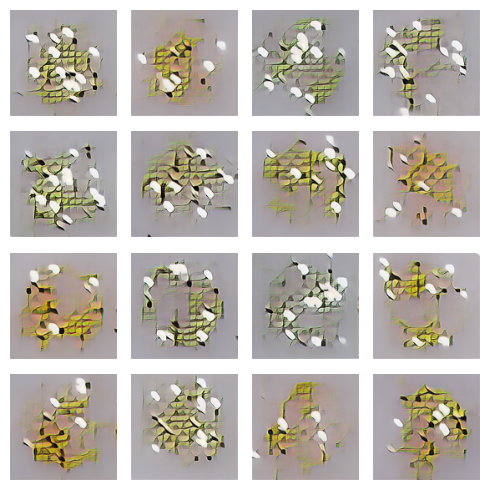

 36%|███▋      | 9078/25000 [52:34<1:29:14,  2.97it/s, loss=3.14e-05]

In [ ]:
loss_history = train_drifting_with_vae(
    vae,
    transformer,
    opt,
    temp=0.5,
    batch_size=32, #256,
    gradient_accumulation=1,
    training_steps=25000,
    plot_every=100,
    seed=None
)